In [1]:
# Task 1
from google.colab import files
uploaded = files.upload()  # select orders_export.csv
import pandas as pd
df = pd.read_csv('orders_export.csv')
print(df.info())
print(df.describe(include='all'))

Saving orders_export.csv to orders_export.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            48 non-null     int64  
 1   company       48 non-null     object 
 2   order_id      48 non-null     int64  
 3   order_date    48 non-null     object 
 4   shipping_fee  48 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.0+ KB
None
               id    company   order_id           order_date  shipping_fee
count   48.000000         48  48.000000                   48     48.000000
unique        NaN         15        NaN                   28           NaN
top           NaN  Company F        NaN  2006-05-24 00:00:00           NaN
freq          NaN          6        NaN                    6           NaN
mean    12.854167        NaN  55.791667                  NaN     44.541667
std      9.815293        NaN  15.7

In [2]:
# Task 2:
import numpy as np

# a. Convert shipping_fee column to a NumPy array, then apply a 10% increase to ALL values at once
fee_array = df['shipping_fee'].to_numpy()
fee_increased = fee_array * 1.10

print("First 5 original values:", fee_array[:5])
print("First 5 increased values:", fee_increased[:5])

# b. Boolean filtering with two conditions combined using &
filtered = df[(df['shipping_fee'] > 10) & (df['shipping_fee'] < 50)]
print("\nRows with shipping_fee between 10 and 50:", len(filtered))

First 5 original values: [  0.   0. 200. 200.  10.]
First 5 increased values: [  0.   0. 220. 220.  11.]

Rows with shipping_fee between 10 and 50: 4


In [3]:
print("Min:", df['shipping_fee'].min())
print("Max:", df['shipping_fee'].max())
print("Mean:", df['shipping_fee'].mean())

Min: 0.0
Max: 300.0
Mean: 44.541666666666664


In [4]:
# Task 3:
fee_array = df['shipping_fee'].to_numpy()
id_array = df['id'].to_numpy()  # using order id as our second numeric column

print("shipping_fee - mean:", np.mean(fee_array))
print("shipping_fee - median:", np.median(fee_array))
print("shipping_fee - std:", np.std(fee_array))
print("shipping_fee - var:", np.var(fee_array))
print("shipping_fee - 90th percentile:", np.percentile(fee_array, 90))

print("\nid - mean:", np.mean(id_array))
print("id - median:", np.median(id_array))
print("id - std:", np.std(id_array))
print("id - var:", np.var(id_array))
print("id - 90th percentile:", np.percentile(id_array, 90))

shipping_fee - mean: 44.541666666666664
shipping_fee - median: 7.0
shipping_fee - std: 77.2236897842164
shipping_fee - var: 5963.49826388889
shipping_fee - 90th percentile: 200.0

id - mean: 12.854166666666666
id - median: 8.5
id - std: 9.712512512504452
id - var: 94.33289930555554
id - 90th percentile: 28.0


In [5]:
# Task 4:
df['order_date'] = pd.to_datetime(df['order_date'])
df['days_since_start'] = (df['order_date'] - df['order_date'].min()).dt.days
df['fee_per_day'] = df['shipping_fee'] / (df['days_since_start'] + 1)

print(df[['order_date', 'days_since_start', 'shipping_fee', 'fee_per_day']].head())

  order_date  days_since_start  shipping_fee  fee_per_day
0 2006-03-24                68           0.0     0.000000
1 2006-05-24               129           0.0     0.000000
2 2006-01-15                 0         200.0   200.000000
3 2006-04-22                97         200.0     2.040816
4 2006-03-10                54          10.0     0.181818


In [7]:
# Task 5:
pivot1 = df.pivot_table(index='company', values='shipping_fee', aggfunc='mean')
pivot2 = df.pivot_table(index='company', values='id', aggfunc='count')
multi_agg = df.groupby('company').agg({'shipping_fee': ['sum', 'mean']})

print(pivot1.head())
print(pivot2.head())
print(multi_agg.head())

            shipping_fee
company                 
Company A       0.000000
Company AA    200.000000
Company BB     25.000000
Company C       4.666667
Company CC    103.500000
            id
company       
Company A    2
Company AA   2
Company BB   4
Company C    3
Company CC   4
           shipping_fee            
                    sum        mean
company                            
Company A           0.0    0.000000
Company AA        400.0  200.000000
Company BB        100.0   25.000000
Company C          14.0    4.666667
Company CC        414.0  103.500000


In [8]:
# Task 6:
def fee_bucket(value):
    if value < 20:
        return 'Low'
    elif value < 100:
        return 'Medium'
    else:
        return 'High'

df['fee_bucket'] = df['shipping_fee'].apply(fee_bucket)
print(df[['shipping_fee', 'fee_bucket']].head(10))

   shipping_fee fee_bucket
0           0.0        Low
1           0.0        Low
2         200.0       High
3         200.0       High
4          10.0        Low
5          40.0     Medium
6          10.0        Low
7          40.0     Medium
8           7.0        Low
9           7.0        Low


In [9]:
# Task 7:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
print(corr_matrix)


                        id  order_id  shipping_fee  days_since_start  \
id                1.000000  0.000488      0.253649          0.023437   
order_id          0.000488  1.000000      0.053508          0.923317   
shipping_fee      0.253649  0.053508      1.000000          0.084973   
days_since_start  0.023437  0.923317      0.084973          1.000000   
fee_per_day       0.216231 -0.245731      0.316769         -0.322054   

                  fee_per_day  
id                   0.216231  
order_id            -0.245731  
shipping_fee         0.316769  
days_since_start    -0.322054  
fee_per_day          1.000000  


In [10]:
# Task 9:
from scipy import stats

t_stat, p_value = stats.ttest_1samp(df['shipping_fee'], 40)

print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Reject H0 - the average shipping fee is significantly different from 40")
else:
    print("Fail to reject H0 - not enough evidence that it differs from 40")

t-statistic: 0.4031936063120522
p-value: 0.6886341726494803
Fail to reject H0 - not enough evidence that it differs from 40


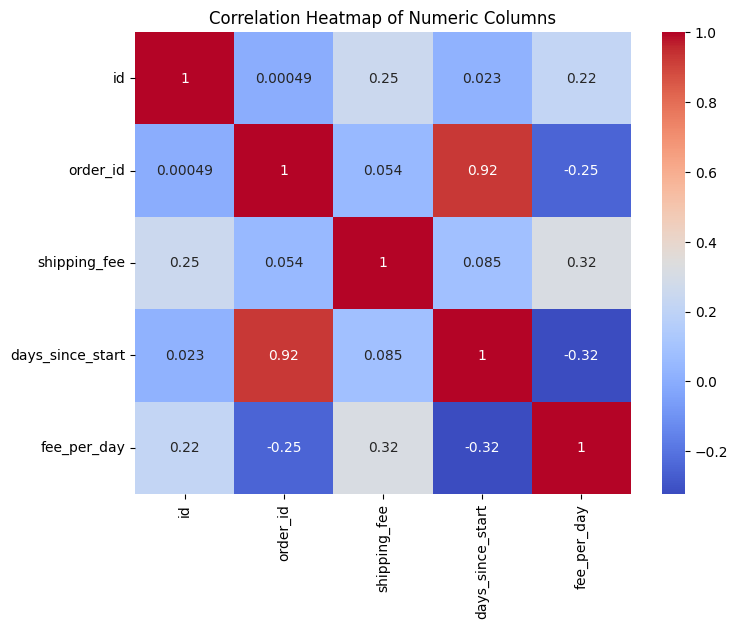

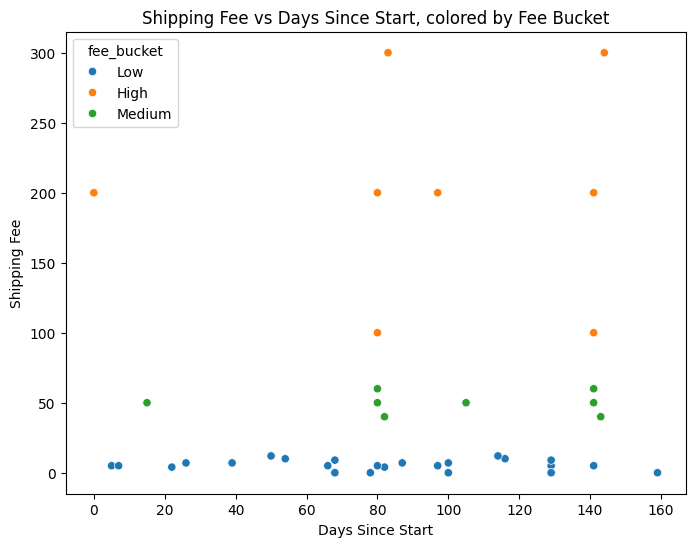

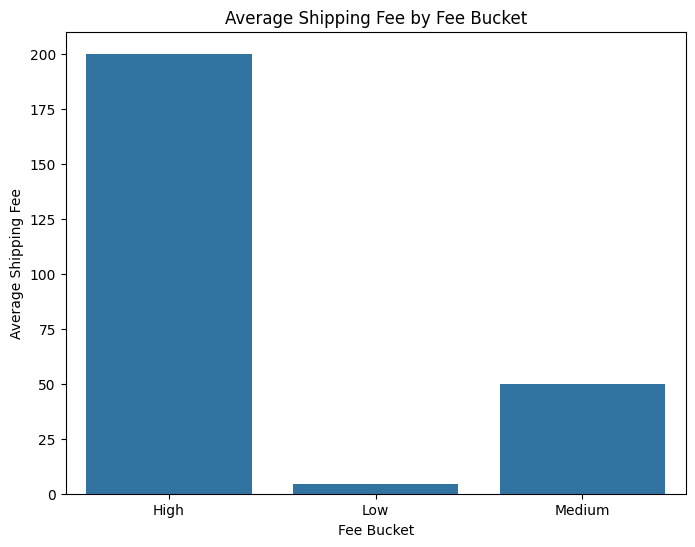

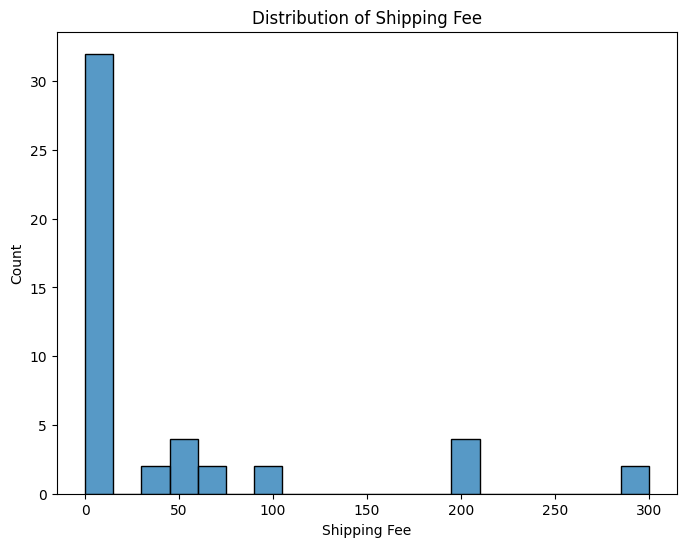

In [14]:
# Task 10:
import matplotlib.pyplot as plt
import seaborn as sns

# a.
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Columns')
plt.savefig('heatmap.png')
plt.show()


# b.
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='days_since_start', y='shipping_fee', hue='fee_bucket')
plt.title('Shipping Fee vs Days Since Start, colored by Fee Bucket')
plt.xlabel('Days Since Start')
plt.ylabel('Shipping Fee')
plt.savefig('scatter.png')
plt.show()


# c.
avg_fee_by_bucket = df.groupby('fee_bucket')['shipping_fee'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=avg_fee_by_bucket, x='fee_bucket', y='shipping_fee')
plt.title('Average Shipping Fee by Fee Bucket')
plt.xlabel('Fee Bucket')
plt.ylabel('Average Shipping Fee')
plt.savefig('barplot.png')
plt.show()


# d.
plt.figure(figsize=(8,6))
sns.histplot(df['shipping_fee'], bins=20)
plt.title('Distribution of Shipping Fee')
plt.xlabel('Shipping Fee')
plt.ylabel('Count')
plt.savefig('histogram.png')
plt.show()
